# Cross-Sectional Stock Return Prediction

This notebook runs the attention experiment from `run_project_mhattn.py`.
This multi-seed notebook is kept with outputs as the main averaged result.


In [1]:
import importlib
import random
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from IPython import get_ipython

ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")
    try:
        from matplotlib_inline.backend_inline import set_matplotlib_formats
        set_matplotlib_formats("png")
    except Exception:
        pass

project_root = Path.cwd().resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import stock_return_core as srp
import run_project_mhattn as mh

srp = importlib.reload(srp)
mh = importlib.reload(mh)
print(srp.__file__)
print(mh.__file__)


/home/hlc/ECE_C147A_Project/stock_return_core.py
/home/hlc/ECE_C147A_Project/run_project_mhattn.py


In [2]:
# Quick run defaults for the averaged attention experiment.
START_DATE = "2015-01-01"
END_DATE = "2025-01-01"
LOOKBACK = 60
HORIZON = 5
UNIVERSE = "small"  # small | sp500 | nasdaq100 | auto
MODELS = ["RNN", "LSTM", "GRU", "TRANSFORMER"]
ATTN_HEADS = 4
DEVICE = mh.resolve_device()
SEEDS = [40, 41, 42]

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        if hasattr(torch.backends, "cudnn"):
            torch.backends.cudnn.benchmark = False
            torch.backends.cudnn.deterministic = True

UNIVERSE_TO_TICKERS = {
    "small": srp.DEFAULT_LIQUID_TICKERS,
    "sp500": srp.SP500_TICKERS,
    "nasdaq100": srp.NASDAQ100_TICKERS,
    "auto": None,
}
TICKERS = UNIVERSE_TO_TICKERS[UNIVERSE]
print(f"Universe: {UNIVERSE}")
print(f"Seeds: {SEEDS}")

# Universe filter: keep stocks that cover nearly the full sample window.
START_BUFFER_DAYS = 5
END_BUFFER_DAYS = 5
MIN_COVERAGE_RATIO = 0.95


Universe: small
Seeds: [40, 41, 42]


In [3]:
raw_prices = srp.download_price_history(start=START_DATE, end=END_DATE, tickers=TICKERS)

flat_prices = srp.flatten_price_frame(raw_prices).dropna(subset=["Close"]).copy()
all_dates = pd.Index(sorted(pd.to_datetime(flat_prices["Date"].unique())))
date_to_pos = {date: idx for idx, date in enumerate(all_dates)}

coverage = (
    flat_prices.groupby("Ticker")
    .agg(
        first_date=("Date", "min"),
        last_date=("Date", "max"),
        n_dates=("Date", "nunique"),
    )
    .reset_index()
)
coverage["first_pos"] = pd.to_datetime(coverage["first_date"]).map(date_to_pos)
coverage["last_pos"] = pd.to_datetime(coverage["last_date"]).map(date_to_pos)
coverage["coverage_ratio"] = coverage["n_dates"] / len(all_dates)

eligible_tickers = coverage.loc[
    (coverage["first_pos"] <= START_BUFFER_DAYS)
    & (coverage["last_pos"] >= len(all_dates) - 1 - END_BUFFER_DAYS)
    & (coverage["coverage_ratio"] >= MIN_COVERAGE_RATIO),
    "Ticker",
].tolist()

filtered_prices = raw_prices.loc[
    :,
    raw_prices.columns.get_level_values(0).isin(eligible_tickers),
]

print(
    f"Kept {len(eligible_tickers)} / {coverage.shape[0]} tickers "
    f"with >= {MIN_COVERAGE_RATIO:.0%} coverage and near-full sample history."
)
print(
    "Dropped examples:",
    coverage.loc[~coverage["Ticker"].isin(eligible_tickers), "Ticker"].head(10).tolist(),
)

experiment_data = srp.prepare_experiment_data(
    filtered_prices,
    horizon=HORIZON,
    lookback=LOOKBACK,
    train_size=0.7,
    val_size=0.15,
)
for split_name, split_df in experiment_data.splits.items():
    print(split_name, split_df["Date"].min(), split_df["Date"].max(), len(split_df))


Kept 49 / 50 tickers with >= 95% coverage and near-full sample history.
Dropped examples: ['UBER']


train 2015-02-02 00:00:00 2021-12-31 00:00:00 85407
val 2022-01-03 00:00:00 2023-06-29 00:00:00 18326
test 2023-06-30 00:00:00 2024-12-23 00:00:00 18326


In [4]:
MODEL_CONFIGS = {
    "RNN": srp.TrainConfig(
        batch_size=128,
        hidden_dim=64,
        num_layers=1,
        dropout=0.0,
        learning_rate=1e-4,
        weight_decay=1e-5,
        max_epochs=20,
        patience=6,
        grad_clip=1.0,
        device=DEVICE,
    ),
    "LSTM": srp.TrainConfig(
        batch_size=128,
        hidden_dim=64,
        num_layers=2,
        dropout=0.15,
        learning_rate=3e-4,
        weight_decay=1e-5,
        max_epochs=25,
        patience=6,
        grad_clip=1.0,
        device=DEVICE,
    ),
    "GRU": srp.TrainConfig(
        batch_size=128,
        hidden_dim=64,
        num_layers=2,
        dropout=0.15,
        learning_rate=1e-4,
        weight_decay=1e-5,
        max_epochs=25,
        patience=6,
        grad_clip=1.0,
        device=DEVICE,
    ),
    "TRANSFORMER": srp.TrainConfig(
        batch_size=256,
        hidden_dim=160,
        num_layers=3,
        dropout=0.15,
        num_heads=8,
        learning_rate=3e-4,
        weight_decay=5e-5,
        max_epochs=35,
        patience=10,
        grad_clip=1.0,
        device=DEVICE,
    ),
}

input_dim = len(experiment_data.feature_columns)
results_by_seed = {}
seed_summaries = []

for seed in SEEDS:
    print(f"=== Seed {seed} ===")
    seed_results = {}
    for model_name in MODELS:
        train_config = MODEL_CONFIGS[model_name]
        set_seed(seed)
        print(f"=== Notebook model: {model_name} (seed={seed}) ===")
        if model_name == "RNN":
            model = srp.build_model(
                model_name="RNN",
                input_dim=input_dim,
                hidden_dim=train_config.hidden_dim,
                num_layers=train_config.num_layers,
                dropout=train_config.dropout,
            )
        elif model_name in {"LSTM", "GRU"}:
            model = mh.AttentionSequenceRegressor(
                input_dim=input_dim,
                hidden_dim=train_config.hidden_dim,
                num_layers=train_config.num_layers,
                dropout=train_config.dropout,
                cell_type=model_name,
                num_attn_heads=ATTN_HEADS,
            )
        elif model_name == "TRANSFORMER":
            model = srp.build_model(
                model_name="TRANSFORMER",
                input_dim=input_dim,
                hidden_dim=train_config.hidden_dim,
                num_layers=train_config.num_layers,
                dropout=train_config.dropout,
                num_heads=train_config.num_heads,
            )
        else:
            raise ValueError(f"Unsupported model: {model_name}")
        seed_results[model_name] = mh.run_experiment(
            model,
            model_name,
            experiment_data,
            train_config,
        )
    results_by_seed[seed] = seed_results
    seed_summary = srp.build_summary_frame(seed_results).copy()
    seed_summary["seed"] = seed
    seed_summaries.append(seed_summary)

all_seed_summaries = pd.concat(seed_summaries, ignore_index=True)
metric_cols = [col for col in all_seed_summaries.columns if col not in {"model", "seed"}]
summary = (
    all_seed_summaries.groupby("model", as_index=False)[metric_cols]
    .mean(numeric_only=True)
    .sort_values("mean_ic", ascending=False)
    .reset_index(drop=True)
)
summary_std = (
    all_seed_summaries.groupby("model", as_index=False)[metric_cols]
    .std(numeric_only=True)
    .rename(columns={col: f"{col}_seed_std" for col in metric_cols})
)
summary = summary.merge(summary_std, left_on="model", right_on="model", how="left")

representative_seed_by_model = {}
for model_name in MODELS:
    target_mean_ic = float(summary.loc[summary["model"] == model_name, "mean_ic"].iloc[0])
    model_rows = all_seed_summaries[all_seed_summaries["model"] == model_name].copy()
    representative_seed = int(model_rows.iloc[(model_rows["mean_ic"] - target_mean_ic).abs().argmin()]["seed"])
    representative_seed_by_model[model_name] = representative_seed

results = {
    model_name: results_by_seed[representative_seed_by_model[model_name]][model_name]
    for model_name in MODELS
}
print("Representative seeds:", representative_seed_by_model)


=== Seed 40 ===
=== Notebook model: RNN (seed=40) ===

=== Training RNN ===


[train] batch 1/645 - loss: 0.039007


[train] batch 200/645 - loss: 0.005502


[train] batch 400/645 - loss: 0.003799


[train] batch 600/645 - loss: 0.003145


...

[val] batch 1/61 - loss: 0.001913


[val] batch 61/61 - loss: 0.002154


Epoch 35/35 - train_loss: 0.001554, val_loss: 0.002154, time: 18.9s


No improvement. Early-stop patience left: 2


Representative seeds: {'RNN': 41, 'LSTM': 42, 'GRU': 42, 'TRANSFORMER': 41}


In [5]:
display(summary)
display(all_seed_summaries)


,model,mean_ic,std_ic,ic_t_stat,mean_rank_ic,std_rank_ic,rank_ic_t_stat,mean_return,volatility,sharpe_ratio,mean_ic_seed_std,std_ic_seed_std,ic_t_stat_seed_std,mean_rank_ic_seed_std,std_rank_ic_seed_std,rank_ic_t_stat_seed_std,mean_return_seed_std,volatility_seed_std,sharpe_ratio_seed_std
0,LSTM,0.066692,0.284214,4.118918,0.045450,0.248014,3.241821,0.005756,0.024541,3.713478,0.016127,0.033085,0.555717,0.005586,0.024224,0.099093,0.001211,0.001585,0.696880
1,GRU,0.063823,0.284306,4.018152,0.043322,0.259575,2.962911,0.005960,0.025794,3.689846,0.009861,0.029680,0.818736,0.011965,0.023038,0.846658,0.001078,0.002931,0.737170
2,TRANSFORMER,0.061505,0.299175,3.615911,0.037881,0.259022,2.525774,0.005287,0.025902,3.209140,0.017955,0.021590,0.865754,0.017344,0.028411,0.909631,0.001853,0.001433,0.979770
3,RNN,0.025367,0.204520,2.181231,0.011869,0.187060,1.114419,0.002093,0.019195,1.724486,0.007858,0.027001,0.482274,0.005129,0.012904,0.463578,0.000708,0.001494,0.522084


,model,mean_ic,std_ic,ic_t_stat,mean_rank_ic,std_rank_ic,rank_ic_t_stat,mean_return,volatility,sharpe_ratio,seed
0,GRU,0.052768,0.298657,3.130874,0.029916,0.247818,2.139084,0.004722,0.025297,2.963282,40
1,LSTM,0.050274,0.254678,3.497947,0.039288,0.222529,3.128540,0.004390,0.023178,3.006928,40
2,TRANSFORMER,0.047105,0.274356,3.042391,0.021405,0.229329,1.653925,0.003580,0.024274,2.341151,40
3,RNN,0.034044,0.233000,2.589101,0.012911,0.200576,1.140641,0.002807,0.020640,2.158832,40
4,LSTM,0.082510,0.319967,4.569470,0.050183,0.270740,3.284494,0.006180,0.026280,3.733240,41
5,GRU,0.071716,0.304083,4.179156,0.047131,0.286120,2.918962,0.006689,0.028941,3.669075,41
6,TRANSFORMER,0.055787,0.309545,3.193562,0.036261,0.261789,2.454415,0.005025,0.026459,3.014728,41
7,RNN,0.023329,0.179293,2.305654,0.006299,0.174870,0.638287,0.002079,0.017656,1.869361,41
8,TRANSFORMER,0.081623,0.313623,4.611781,0.055979,0.285949,3.468983,0.007258,0.026972,4.271542,42
9,LSTM,0.067292,0.277998,4.289335,0.046877,0.250773,3.312428,0.006698,0.024165,4.400267,42


# Result Visualizations

Plots for loss curves, IC/RankIC, portfolio performance, and model comparison.


Visualizing model: LSTM (representative seed=42)


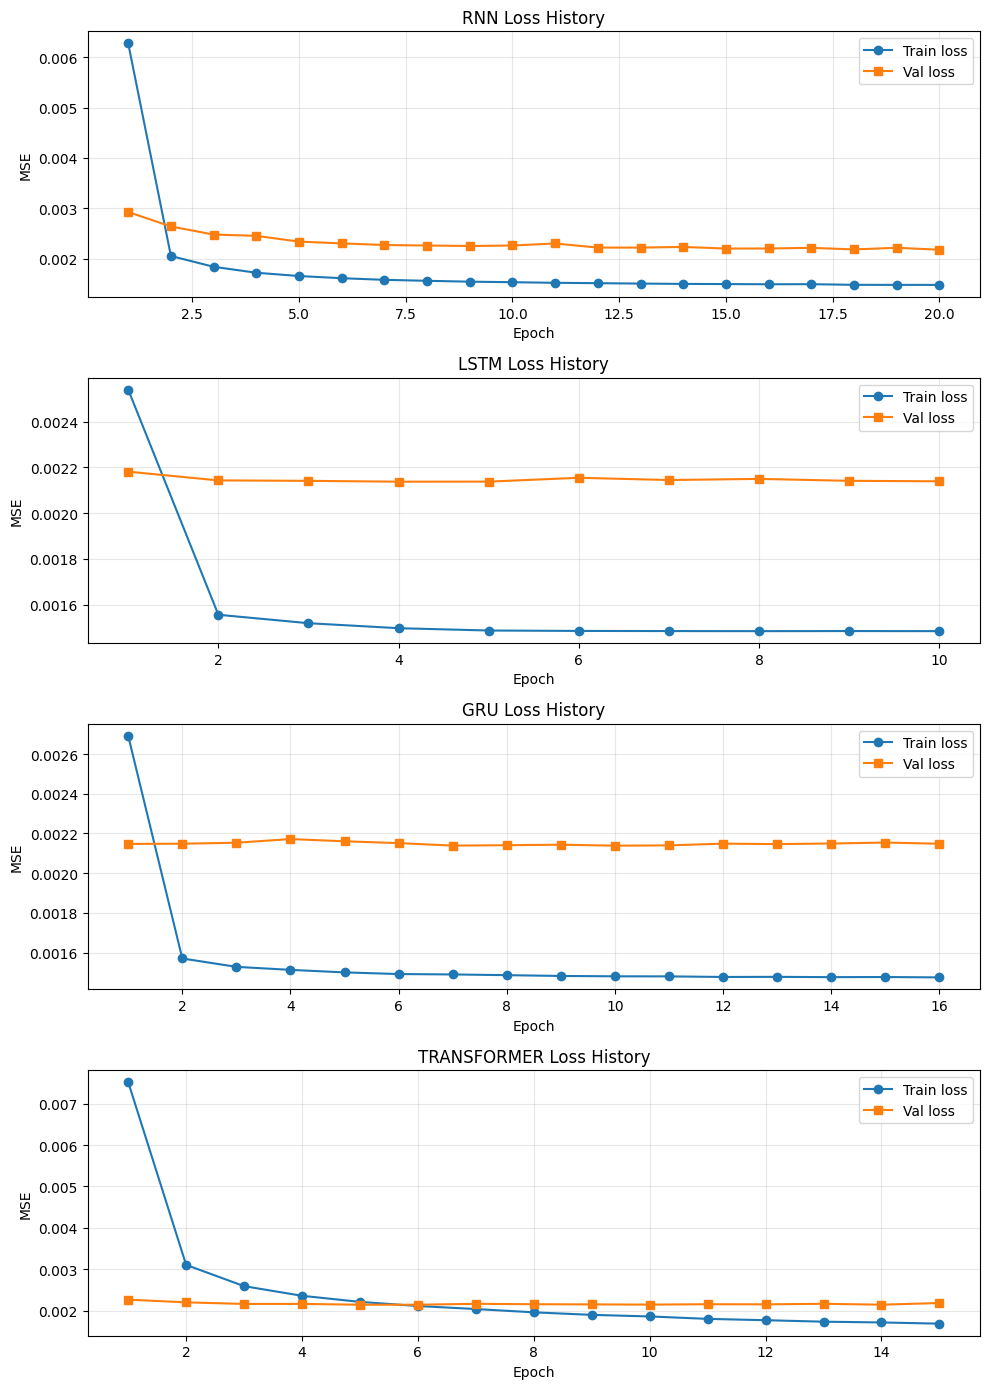

In [ ]:
import matplotlib.pyplot as plt

best_model = summary.iloc[0]["model"]
best_seed = representative_seed_by_model[best_model]
print(f"Visualizing model: {best_model} (representative seed={best_seed})")
training_fig = srp.plot_training_histories(results)
display(training_fig)
plt.close(training_fig)


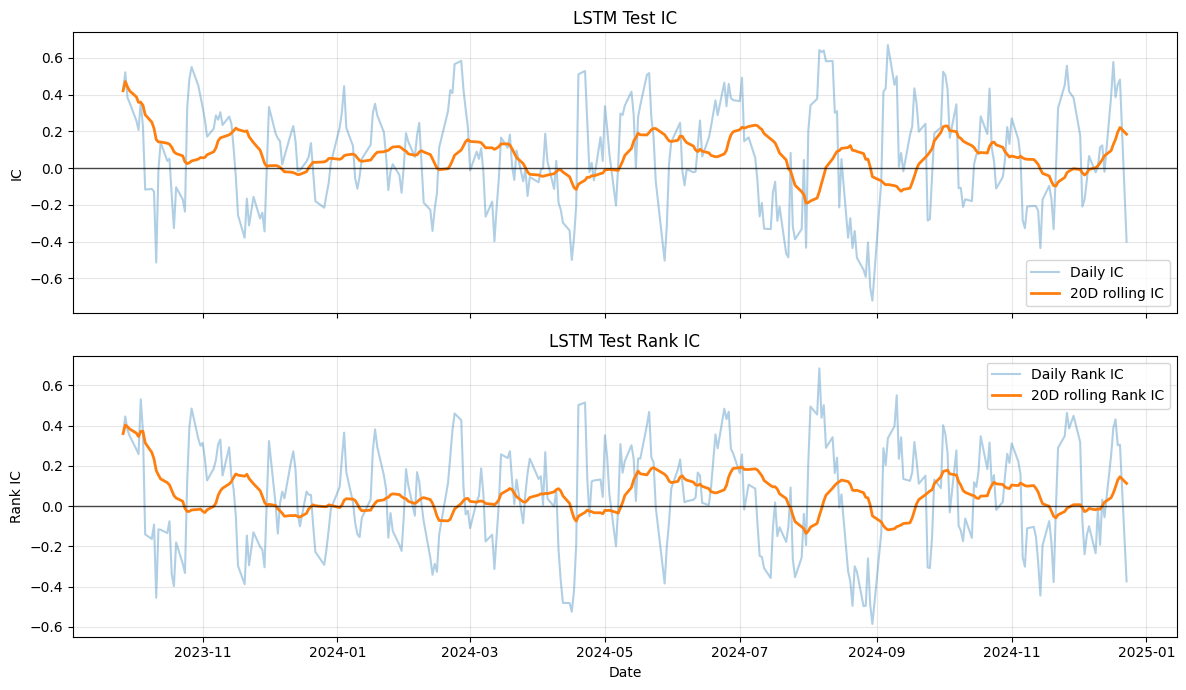

In [7]:
import matplotlib.pyplot as plt

ic_fig = srp.plot_ic_series(results, best_model, split="test", rolling_window=20)
display(ic_fig)
plt.close(ic_fig)


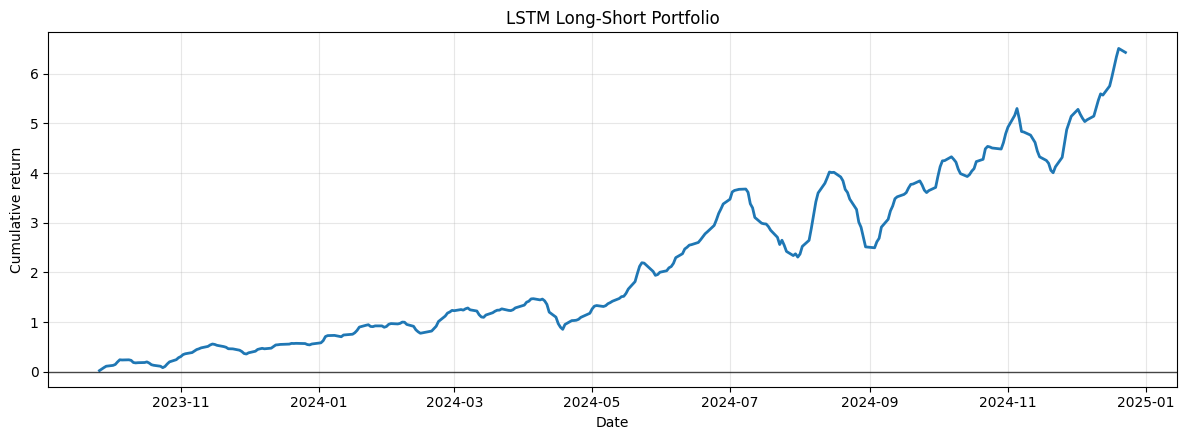

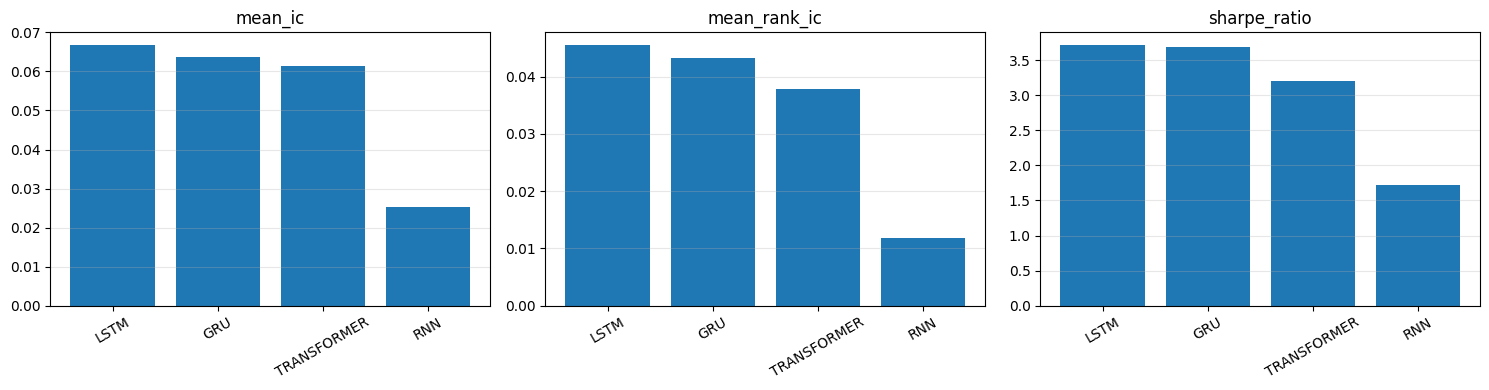

In [8]:
import matplotlib.pyplot as plt

for model_name, result in results.items():
    if "portfolio_curve" not in result:
        portfolio_curve, portfolio_summary = srp.backtest_long_short(result["test_predictions"])
        result["portfolio_curve"] = portfolio_curve
        result["portfolio_summary"] = portfolio_summary

portfolio_fig = srp.plot_portfolio_curve(results, best_model)
summary_fig = srp.plot_summary_bars(summary)
display(portfolio_fig)
display(summary_fig)
plt.close(portfolio_fig)
plt.close(summary_fig)


# Prediction diagnostics

Inspect raw predictions, sign accuracy, and the prediction-vs-target scatter plot.


In [9]:
model_name = best_model
seed_used = representative_seed_by_model[model_name]
print(f"Prediction diagnostics use representative seed: {seed_used}")
pred = results[model_name]["test_predictions"].copy()
pred.head()


Prediction diagnostics use representative seed: 42


,Date,Ticker,prediction,target
0,2023-09-26,AAPL,0.003889,0.002559
1,2023-09-26,ABBV,0.002194,-0.042103
2,2023-09-26,ABT,0.002116,-0.004572
3,2023-09-26,ADBE,0.005027,0.001442
4,2023-09-26,AMD,0.012898,0.042935


In [10]:
pred["pred_sign"] = (pred["prediction"] > 0).astype(int)
pred["true_sign"] = (pred["target"] > 0).astype(int)

sign_accuracy = (pred["pred_sign"] == pred["true_sign"]).mean()
daily_sign_accuracy = pred.groupby("Date").apply(
    lambda x: ((x["prediction"] > 0) == (x["target"] > 0)).mean(),
    include_groups=False,
)

print("Overall sign accuracy:", round(float(sign_accuracy), 4))
daily_sign_accuracy.describe()


Overall sign accuracy: 0.5644


count    314.000000
mean       0.564409
std        0.203137
min        0.081633
25%        0.428571
50%        0.571429
75%        0.714286
max        1.000000
dtype: float64

,Date,Ticker,prediction,target,pred_sign,true_sign
15340,2024-12-23,ADBE,0.008689,-0.004611,1,0
15381,2024-12-23,UNH,0.007771,-0.000948,1,0
15341,2024-12-23,AMD,0.007447,-0.030578,1,0
15378,2024-12-23,QCOM,0.007177,-0.029196,1,0
15372,2024-12-23,NVDA,0.006951,-0.038519,1,0
15364,2024-12-23,LLY,0.005990,-0.030492,1,0
15359,2024-12-23,INTU,0.005814,-0.015353,1,0
15367,2024-12-23,META,0.005584,-0.023906,1,0
15344,2024-12-23,AVGO,0.005090,-0.002195,1,0
15343,2024-12-23,AMZN,0.004963,-0.025193,1,0


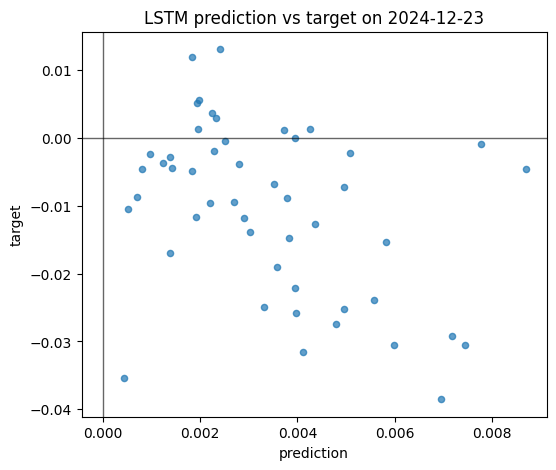

In [11]:
import matplotlib.pyplot as plt

latest_day = pred["Date"].max()
latest_slice = pred[pred["Date"] == latest_day].copy()
display(latest_slice.sort_values("prediction", ascending=False).head(10))

ax = latest_slice.plot.scatter(
    x="prediction",
    y="target",
    figsize=(6, 5),
    alpha=0.7,
    title=f"{model_name} prediction vs target on {latest_day.date()}"
)
ax.axhline(0.0, color="black", linewidth=1, alpha=0.6)
ax.axvline(0.0, color="black", linewidth=1, alpha=0.6)
plt.show()
